# The Divided Danish Home — Explainer Notebook

## 1. Motivation

This project investigates regional housing price fluctuations across Denmark 
and explores potential drivers behind them. This includes local income levels, 
population growth, and macroeconomic factors such as interest rates and inflation.

### What is the dataset?

This project is built on three merged datasets covering all 98 Danish municipalities from 2008 to 2024:
1. **Housing Transactions (1992-2024):** [Danish Residential Housing Prices 1992-2024 - Kaggle](https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024/data) 1,028,034 individual residential sales sourced from the Danish Residential Housing Prices 1992–2024 dataset on Kaggle (compiled from public property registers). Each row represents a single transaction and includes: purchase price, square metre price, property size, zip code, number of rooms, nominal interest rate at time of sale, inflation rate, yield on mortgage credit bonds, and the percentage change between offer and final purchase price.

2. **Municipal Income Data:** [Statistics Denmark - INDKF132](https://www.statistikbanken.dk/statbank5a/SelectVarVal/define.asp?MainTable=INDKF132&PLanguage=1&Tabstrip=&PXSId=0&SessID=618176180&FF=20&tfrequency=1) Annual average disposable household income at municipality level, drawn from Statistics Denmark's income register (INDKF132). The data is disaggregated by household type (families, couples, singles) and averaged across types to produce a single representative annual income figure per municipality per year.

3. **Population Data:** [Statistics Denmark - FOLK1E](https://www.statistikbanken.dk/FOLK1E)
Quarterly population counts per municipality from Statistics Denmark (FOLK1E), averaged across four quarters to produce yearly figures.

4. **Municipality Boundaries:** [Denmark Municipalities GeoJSON](https://github.com/codeforgermany/click_that_hood/blob/main/public/data/denmark-municipalities.geojson) Geographic boundary data defining the shapes of all 98 Danish municipalities, used for map rendering throughout the project.

Central to this analysis is an affordability index, defined as:

> Affordability = Mean Annual Income / Mean sqm Price

A higher index means housing is more affordable relative to local earnings. This formulation is intentionally simple: it captures purchasing power in the housing market without requiring assumptions about mortgage terms, deposit sizes, or household composition.

### Why did we choose this dataset?

Housing affordability is one of the most consequential socioeconomic issues in contemporary Denmark and in much of the wealthy world. Yet public debate tends to focus on a single narrative: that Copenhagen is unaffordable. This overlooks the broader picture: that affordability differs dramatically across Danish municipalities, and that price alone tells only half the story 
without considering local income levels.

We chose this dataset because it allows us to move beyond the Copenhagen narrative and examine housing affordability across all 98 Danish municipalities. It combines price, income, and population data to capture the full picture that public debate 
often misses. With transaction-level data covering every municipality over 17 years, we can trace not just what happened to prices, but what it meant for people's lives: whether they could afford to buy, where they chose to live, and how the gap between Denmark's most and least accessible housing markets has evolved over time.

We were also motivated by a personal connection to the question. As students living in Copenhagen, which is one of the least affordable municipalities in Denmark, the divide between urban and rural housing markets is not abstract. It shapes decisions about where to rent, whether ownership is realistic, and what trade-offs between opportunity and cost look like for a generation entering the housing market.

### What was our goal for the end user's experience?

Our goal was to guide the reader through a layered, progressively revealing story that moves from national aggregates to regional patterns to individual municipalities. We wanted the experience to feel like discovery, not report-reading.

Concretely:

* Non-technical readers (the primary audience) should be able to follow the narrative without understanding the underlying data structures. Every chart is accompanied by interpretive prose. Technical jargon is avoided; the affordability index is explained once, clearly, and then used consistently throughout.

* For the curious readers who want to explore, we included interactive charts. They can hover over municipalities, scroll through time, toggle between layers on the map and find their own city and tracing its trajectory.

* The structure follows a martini glass narrative (see Genre section below): a guided story first, then a deliberate handoff to free exploration, signalled visually by the transition section midway through the website  ([Segel & Heer, 2010](#references)).

## 2. Basic Stats

### Data Cleaning and Preprocessing

In [ ]:
import os, json
import numpy as np
import pandas as pd

# ── Name standardisation map ─────────────────────────────────────────────────
# Several municipalities appear under different spellings across data sources.
# All variants are mapped to the GeoJSON-compatible canonical name here,
# so that merges work correctly throughout.

MUN_RENAME = {
    'Copenhagen':       'Københavns',         # English name in Kaggle dataset
    'København':        'Københavns',         # Missing trailing 's'
    'Vesthimmerland':   'Vesthimmerlands',    # Missing trailing 's'
    'Christiansø':      'Bornholms Regionskommune',  # Tiny island, merged with Bornholm
    'Bornholm':         'Bornholms Regionskommune',  # GeoJSON uses full regional name
    'Nordfyn':          'Nordfyns',           # Missing trailing 's'
}

Key decisions in data cleaning:

* Municipality name standardisation was the single biggest source of friction. The Kaggle housing dataset uses English names (e.g. "Copenhagen"), the Statistics Denmark income data uses Danish short forms (e.g. "København"), and the GeoJSON boundary file uses official administrative names (e.g. "Københavns"). A single `MUN_RENAME` dictionary is defined once and applied consistently across all three sources to ensure clean joins.

* Christiansø is a tiny island near Bornholm with a handful of permanent residents and almost no housing transactions. Therefore, it was merged into Bornholms Regionskommune in both the population and housing data, matching the [Denmark Municipalities GeoJSON](https://github.com/codeforgermany/click_that_hood/blob/main/public/data/denmark-municipalities.geojson) boundary file which does not include it as a separate feature.

* Population averaging: Raw population data from Statistics Denmark is quarterly (Q1–Q4). We average the four quarters to produce a single yearly figure, which better represents the annual average than any single quarter. This matters for 
the affordability index, which uses annual income and annual average sqm price.

* Year filter: The Kaggle housing dataset extends back to 1992, but income and population data are only reliably available from 2008. All analysis is therefore restricted to 2008–2024.

* Urban/Rural classification: Municipalities are classified as Urban or Rural based on whether their 2024 population is above or below the national median across all 98 municipalities. The median threshold in 2024 is approximately 42,000 residents. This is a pragmatic binary classification, since it does not capture every nuance, but holds well at the aggregate level and allows for comparisons between densely and sparsely populated parts of Denmark.

* Zip-to-municipality mapping: The Kaggle housing data uses zip codes, not municipality names. Zip codes were resolved to municipality names using the [DAWA API](https://dawadocs.dataforsyningen.dk/) (Danmarks Adressers Web API). It is the official Danish address register maintained by the Danish Agency for Data Supply and Infrastructure. The resulting lookup was saved as 
`zip_to_muni_clean.json`. Several zip codes were mapped to the wrong municipality because some postal districts span multiple municipal boundaries. In these cases the API returns the dominant municipality rather than the correct one (e.g. zip 
code 2610 was mapped to Copenhagen rather than Rødovre, and 9500 to Viborg rather than Mariagerfjord). These cases were identified by checking which municipalities were missing from the dataset and corrected manually.

* Income aggregation: The Statistics Denmark income register (INDKF132) disaggregates income by household type (families, couples, singles). These are averaged across types to produce a single representative annual income figure per municipality per year, used as the income input to the affordability index.

* Housing data aggregation: The raw housing data contains one row per transaction. To make it compatible with the income and population datasets, which are both structured as yearly numbers per municipality and per region, the housing data was likewise aggregated to annual figures per municipality and per region. For each group, we computed the mean and median purchase price, mean sqm price, mean property size, mean number of rooms, and total number of sales per year.

* Final datasets: The three cleaned and aggregated datasets were merged into two unified datasets covering 
2008 to 2024. The first one is at municipality level and the second at region level, where numbers for municipality are aggregated. These are loaded below and form the basis for all analysis in this notebook.

### Exploratory Data Analysis

In [10]:
df_mun = pd.read_csv('FinalData/mun_explainer_data.csv')
df_reg = pd.read_csv('FinalData/reg_explainer_data.csv')

# ── Shape and coverage ────────────────────────────────────────────────────────
print('df_mun shape:', df_mun.shape)        # (1666, 19) — 98 municipalities × 17 years
print('df_reg shape:', df_reg.shape)        # (85, 16)  — 5 regions × 17 years
print('Year range:', df_mun['year'].min(), '–', df_mun['year'].max())
print('Municipalities:', df_mun['Municipality'].nunique())
print('Regions:', df_mun['Region'].nunique())
print('Columns in df_mun:', df_mun.columns.tolist())
print('Columns in df_reg:', df_reg.columns.tolist())

print('\nAffordability index summary:')
print(df_mun['affordability'].describe())

print('\nSqm price summary (DKK):')
print(df_mun['sqm_price_mean'].describe())

print('\nIncome summary (DKK):')
print(df_mun['income'].describe())

print('\nPopulation summary:')
print(df_mun['population'].describe())

df_mun shape: (1666, 19)
df_reg shape: (85, 16)
Year range: 2008 – 2024
Municipalities: 98
Regions: 5
Columns in df_mun: ['Municipality', 'Region', 'year', 'purchase_price_mean', 'purchase_price_median', 'sqm_price_mean', 'sqm_price_median', 'sqm_mean', 'no_rooms_mean', '%_change_between_offer_and_purchase_mean', 'nom_interest_rate%_mean', 'dk_ann_infl_rate%_mean', 'yield_on_mortgage_credit_bonds%_mean', 'no_sales', 'income', 'population', 'affordability', 'sales_per_1000', 'urban_rural']
Columns in df_reg: ['Region', 'year', 'purchase_price_mean', 'purchase_price_median', 'sqm_price_mean', 'sqm_price_median', 'sqm_mean', 'no_rooms_mean', '%_change_between_offer_and_purchase_mean', 'nom_interest_rate%_mean', 'dk_ann_infl_rate%_mean', 'yield_on_mortgage_credit_bonds%_mean', 'no_sales', 'income', 'population', 'affordability']

Affordability index summary:
count    1666.000000
mean       25.170152
std         7.448746
min         8.480086
25%        19.419440
50%        25.077788
75%    

In [13]:
print('Most affordable (max affordability):')
print(df_mun.loc[df_mun['affordability'].idxmax(), ['Municipality', 'year', 'affordability']])

print('\nLeast affordable (min affordability):')
print(df_mun.loc[df_mun['affordability'].idxmin(), ['Municipality', 'year', 'affordability']])

print('\nHighest square metre price (max sqm price):')
print(df_mun.loc[df_mun['sqm_price_mean'].idxmax(), ['Municipality', 'year', 'sqm_price_mean']])

print('\nLowest square metre price (min sqm_price_meany):')
print(df_mun.loc[df_mun['sqm_price_mean'].idxmin(), ['Municipality', 'year', 'sqm_price_mean']])

Most affordable (max affordability):
Municipality      Ringsted
year                  2014
affordability    57.313316
Name: 1213, dtype: object

Least affordable (min affordability):
Municipality     Frederiksberg
year                      2022
affordability         8.480086
Name: 354, dtype: object

Highest square metre price (max sqm price):
Municipality      Frederiksberg
year                       2024
sqm_price_mean        61979.387
Name: 356, dtype: object

Lowest square metre price (min sqm_price_meany):
Municipality           Ærø
year                  2015
sqm_price_mean    6037.877
Name: 1656, dtype: object


The municipality dataset (`df_mun`) contains 19 columns across 1,666 rows (98 municipalities × 17 years). The region dataset (`df_reg`) contains 16 columns across 85 rows (5 regions × 17 years). The three columns present in `df_mun` but not in `df_reg` are:
* `Municipality` — replaced by `Region` as the geographic identifier
* `sales_per_1000` — sales per 1,000 inhabitants, which is only meaningful at municipality level where population differences are large enough to matter
* `urban_rural` — a municipality-level classification that has no equivalent at region level, as all five regions contain both urban and rural municipalities

Additionally findings from the basic statistics about the data:

* The affordability index ranges from ~8 (Frederiksberg in 2022) to ~57 (Ringsted in 2014), a difference of nearly 7 times between the least and most affordable municipalities. This alone signals that "national average" figures mask enormous local variation.
* The standard deviation of affordability (~7.4) is large relative to the mean (~25.2), confirming that the distribution is wide and heterogeneous.
* Square metre prices span from ~6,000 DKK/sqm (Ærø in 2015) to ~62,000 DKK/sqm (Frederiksberg in 2024), which is more than 10 times higher.
* Income variation is comparatively modest, with a 4-fold range between lowest and highest earning municipalities. It confirms that income differences alone cannot explain the affordability divide. The housing price divergence plays the biggest role.

In [79]:
# ── Transactions per year ─────────────────────────────────────────────────────
tx_by_year = df_mun.groupby('year')['no_sales'].sum()
print(tx_by_year)

year
2008     35781
2009     31193
2010     39845
2011     34489
2012     37075
2013     39646
2014     45820
2015     57217
2016     55896
2017     36345
2018     79110
2019     86439
2020    103857
2021    118350
2022     81815
2023     83921
2024     61235
Name: no_sales, dtype: int64


In [16]:
# ── Interest rates per year ─────────────────────────────────────────────────────
ir_by_year = df_mun.groupby('year')['nom_interest_rate%_mean'].mean()
print(ir_by_year)

year
2008    4.045341
2009    1.859150
2010    0.806982
2011    0.990996
2012    0.436096
2013    0.000000
2014    0.000000
2015    0.000000
2016    0.000000
2017    0.000000
2018    0.000000
2019    0.000000
2020    0.000000
2021    0.000000
2022    0.122879
2023    2.816287
2024    3.517754
Name: nom_interest_rate%_mean, dtype: float64


Transaction volume roughly tripled between 2008 and 2021, then crashed about 30% in a single year following the rapid interest rate rise of 2022–2023. The nominal rate jumped from effectively 0% to over 3.5% in just two 
years after a decade of near-zero rates. This represents one of the sharpest 
single-year contractions in the dataset. 

In [18]:
# ── Aggregated Affordability Across Regions Per year ─────────────────────────────────────
national_avg = df_reg.groupby('year')['affordability'].mean().round(2)
print(national_avg)

year
2008    19.43
2009    21.28
2010    23.02
2011    22.65
2012    24.68
2013    24.60
2014    24.91
2015    24.15
2016    23.74
2017    23.40
2018    23.45
2019    23.49
2020    23.05
2021    22.40
2022    22.55
2023    23.78
2024    23.69
Name: affordability, dtype: float64


The national average affordability index rose sharply from 19.4 in 2008 to 23.0 in 2010, as house prices fell in the wake of the global financial crisis while incomes remained relatively stable ([Dam et al., 2011](https://www.nationalbanken.dk/en/publications/monetary-review)). Affordability then plateaued around 23–25 throughout the 2010s, before declining again from 2020 to 2022, whcih can be due to the post-pandemic pushed sqm prices up faster than incomes. The slight recovery in 2023–2024 might reflect the rising interest rates on house prices ([Danmarks Nationalbank, 2024](https://www.nationalbanken.dk/en/news-and-knowledge/publications-and-speeches/analysis/2024/big-shocks-to-the-economy-have-fuelled-house-prices)).

In [19]:
# ── Affordability by region: 2008 vs 2024 ─────────────────────────────────────
comp = df_reg[df_reg['year'].isin([2008, 2014, 2024])][['Region','year','affordability']]
print(comp.pivot(index='Region', columns='year', values='affordability').round(2))

year               2008   2014   2024
Region                               
Capital Region    14.73  17.76  14.69
Central Jutland   20.82  25.34  23.42
North Jutland     21.29  28.76  28.07
Southern Denmark  20.13  25.06  26.78
Zealand Region    20.18  27.65  25.49


It implies that 2008 represents a particularly unfavourable baseline, since it marks the peak of the 2000s Danish property bubble ([Wikipedia, 2024](https://en.wikipedia.org/wiki/Danish_property_bubble_of_2000s); [Dam et al., 2011](https://www.nationalbanken.dk/en/publications/monetary-review)). House prices fell by 11.1% in 2008 alone, meaning that sqm prices at the start of our dataset were unusually elevated relative to incomes.

A more revealing comparison is 2014, which was the affordability peak across all regions, with a mean affordability index of 24.91. Most regions show a decline in affordability between 2014 and 2024, with Capital Region hit hardest, dropping from 17.76 to 14.69. Zealand Region and Central Jutland are also notably affected, while North Jutland shows only a minor decrease. Southern Denmark is the exception, recording an increase in affordability over the same period. 

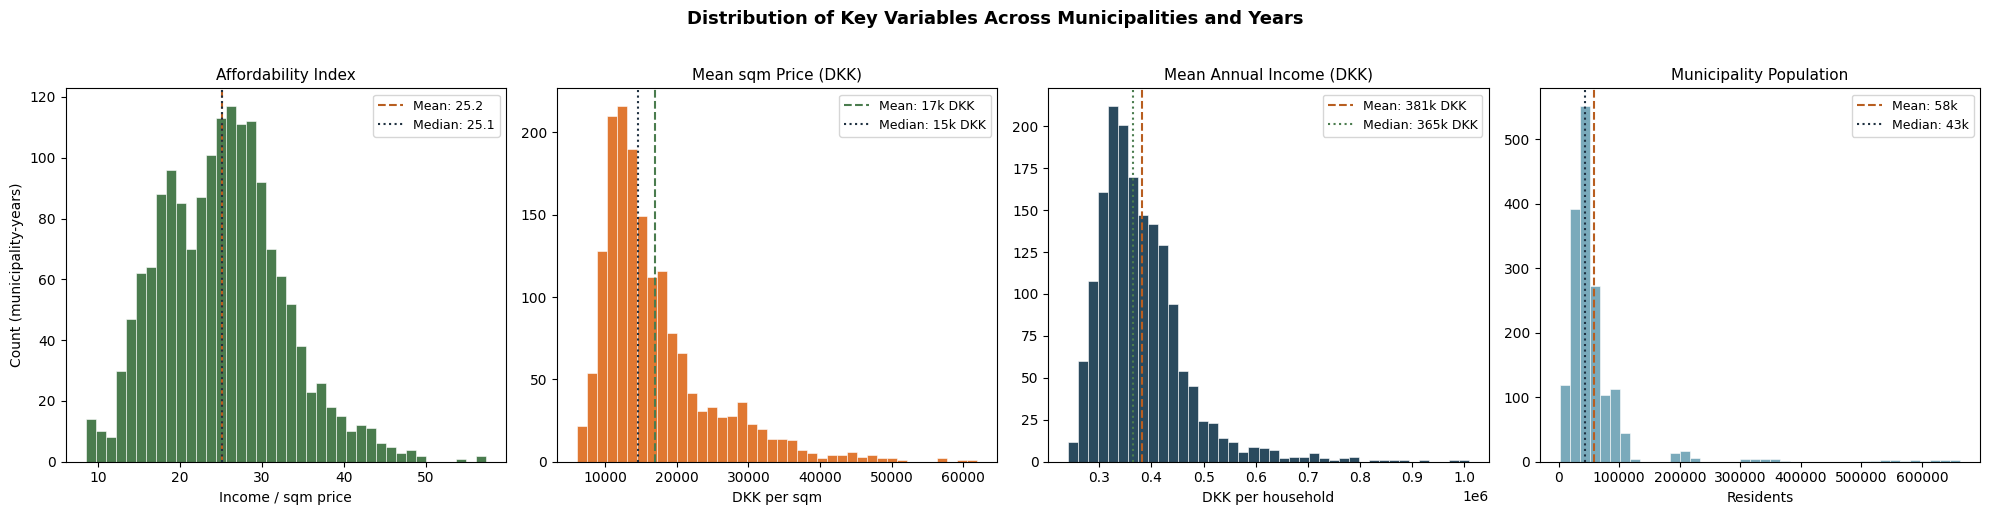

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Distribution of Key Variables Across Municipalities and Years', 
             fontsize=13, fontweight='bold', y=1.02)

# ── Affordability index ───────────────────────────────────────────────────────
axes[0].hist(df_mun['affordability'], bins=40, color='#4a7c4e', edgecolor='white', linewidth=0.4)
axes[0].axvline(df_mun['affordability'].mean(), color='#b85e20', linestyle='--', linewidth=1.5, label=f"Mean: {df_mun['affordability'].mean():.1f}")
axes[0].axvline(df_mun['affordability'].median(), color='#1e3040', linestyle=':', linewidth=1.5, label=f"Median: {df_mun['affordability'].median():.1f}")
axes[0].set_title('Affordability Index', fontsize=11)
axes[0].set_xlabel('Income / sqm price')
axes[0].set_ylabel('Count (municipality-years)')
axes[0].legend(fontsize=9)

# ── Sqm price ────────────────────────────────────────────────────────────────
axes[1].hist(df_mun['sqm_price_mean'], bins=40, color='#e07832', edgecolor='white', linewidth=0.4)
axes[1].axvline(df_mun['sqm_price_mean'].mean(), color='#4a7c4e', linestyle='--', linewidth=1.5, label=f"Mean: {df_mun['sqm_price_mean'].mean()/1000:.0f}k DKK")
axes[1].axvline(df_mun['sqm_price_mean'].median(), color='#1e3040', linestyle=':', linewidth=1.5, label=f"Median: {df_mun['sqm_price_mean'].median()/1000:.0f}k DKK")
axes[1].set_title('Mean sqm Price (DKK)', fontsize=11)
axes[1].set_xlabel('DKK per sqm')
axes[1].set_ylabel('')
axes[1].legend(fontsize=9)

# ── Income ───────────────────────────────────────────────────────────────────
axes[2].hist(df_mun['income'], bins=40, color='#2a4a5e', edgecolor='white', linewidth=0.4)
axes[2].axvline(df_mun['income'].mean(), color='#b85e20', linestyle='--', linewidth=1.5, label=f"Mean: {df_mun['income'].mean()/1000:.0f}k DKK")
axes[2].axvline(df_mun['income'].median(), color='#4a7c4e', linestyle=':', linewidth=1.5, label=f"Median: {df_mun['income'].median()/1000:.0f}k DKK")
axes[2].set_title('Mean Annual Income (DKK)', fontsize=11)
axes[2].set_xlabel('DKK per household')
axes[2].set_ylabel('')
axes[2].legend(fontsize=9)

# ── Population ───────────────────────────────────────────────────────────────
axes[3].hist(df_mun['population'], bins=40, color='#7aaabb', edgecolor='white', linewidth=0.4)
axes[3].axvline(df_mun['population'].mean(), color='#b85e20', linestyle='--', linewidth=1.5, label=f"Mean: {df_mun['population'].mean()/1000:.0f}k")
axes[3].axvline(df_mun['population'].median(), color='#1e3040', linestyle=':', linewidth=1.5, label=f"Median: {df_mun['population'].median()/1000:.0f}k")
axes[3].set_title('Municipality Population', fontsize=11)
axes[3].set_xlabel('Residents')
axes[3].set_ylabel('')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.savefig('Figures/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

All four histograms show right-skewed distributions, though to varying degrees. Sqm prices are the most skewed, where most municipalities record between 10k and 15k DKK per sqm, but a small number of expensive urban municipalities push the mean (17k) above the median (15k). Income follows a similar but milder pattern, with mean (381k) and median (365k) relatively close together. The affordability index is the most symmetric of the four, with mean (25.2) and median (25.1) almost identical, which suggests that the skews in price and income roughly cancel each other out when combined into the index. Population is the most extreme case, where the median municipality has 43k residents but the mean is pulled up to 58k by a small number of large municipalities such as Copenhagen with over 660k residents.

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_27242/349562418.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  national_by_year = df_mun.groupby('year').apply(


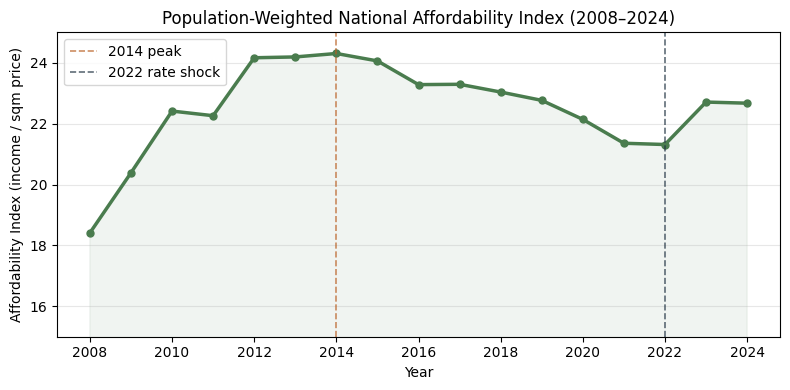

In [21]:
national_by_year = df_mun.groupby('year').apply(
    lambda x: np.average(x['affordability'], weights=x['population'])
).reset_index()
national_by_year.columns = ['year', 'affordability']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(national_by_year['year'], national_by_year['affordability'], 
        color='#4a7c4e', linewidth=2.5, marker='o', markersize=5)
ax.axvline(2014, color='#b85e20', linestyle='--', linewidth=1.2, alpha=0.7, label='2014 peak')
ax.axvline(2022, color='#1e3040', linestyle='--', linewidth=1.2, alpha=0.7, label='2022 rate shock')
ax.fill_between(national_by_year['year'], national_by_year['affordability'], 
                alpha=0.08, color='#4a7c4e')
ax.set_title('Population-Weighted National Affordability Index (2008–2024)', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Affordability Index (income / sqm price)')
ax.set_ylim(15, 25)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figures/national_trend_eda.png', dpi=150, bbox_inches='tight')
plt.show()

The plot shows the national affordability index from 2008 to 2024, where each year's value is a population-weighted average across all 98 municipalities. Population-weighting means that larger municipalities count more than smaller ones — Copenhagen's affordability has more influence on the national figure than Læsø's, which better reflects where most Danes actually live and buy homes.

The trend tells a clear two-phase story. Affordability rose sharply from 2008 to a peak around 2012 to 2014, as house prices fell following the financial crisis and interest rates dropped toward zero. From 2015 onward, a slow decline set in as price growth outpaced income growth across most of the country. The 2022 interest rate rise ([Danmarks Nationalbank, 2024](https://www.nationalbanken.dk/en/news-and-knowledge/publications-and-speeches/analysis/2024/big-shocks-to-the-economy-have-fuelled-house-prices)) is visible as a sharp downward step, bottoming out in 2021 to 2022. Notably, affordability had already been falling for several years before rates rose, which suggests the rate shock accelerated an existing trend rather than causing a new one. A partial recovery is visible in 2023 to 2024, likely reflecting modest price corrections as the market adjusted to higher borrowing costs.



The national trend makes the two-phase story immediately legible. Affordability rose from the post-crisis trough in 2008 to a clear peak around 2012–2014, driven by falling prices and low interest rates. From 2015 onward, a slow but broadly uninterrupted decline set in as price growth outpaced income growth. The 2022 rate shock is visible as a downward step that bottomed out in 2021–2022 — though notably, affordability had already been eroding for several years before rates rose, suggesting the shock accelerated an existing trend rather than creating a new one. A partial recovery is visible in 2023–2024, likely reflecting modest price corrections as the market adjusted to higher borrowing costs.

## 3. Data Analysis

### What we learned about the dataset

**Finding 1: The affordability cycle has two distinct phases**

Denmark experienced a clear affordability improvement from 2008 to ~2014, driven by the post-bubble correction in house prices and low interest rates pulling down the cost of financing. This was followed by a slow deterioration from 2015 onward as prices recovered and demand — particularly in urban areas — outstripped supply. The 2022 interest rate shock delivered a sharp, rapid decline that compressed both affordability and transaction volume simultaneously.

**Finding 2: The urban–rural divide is structural, not cyclical**

When municipalities are classified as Urban or Rural and their population-weighted affordability is tracked over time, the gap that opened between 2009 and 2016 has never closed. At its widest, the rural affordability advantage was approximately 5 index points (roughly a 20% premium in purchasing power). By 2024, rural areas still hold a 1–2 point advantage, but the gap is narrowing — not because cities improved, but because rural areas also declined.

**Finding 3: Price growth, not income stagnation, drives the crisis**

Across all five regions, household income roughly doubled between 2008 and 2024 — a consistent, broad-based rise. Square metre prices, however, rose 150–170% in Capital Region municipalities while rising only 20–40% in large parts of Jutland. The affordability crisis is not a wage story; it is a housing supply story. Where housing supply failed to keep pace with demand (dense urban centres), prices disconnected from incomes. Where supply was adequate (rural municipalities), affordability broadly held.

**Finding 4: The migration paradox — people moved toward expensive cities anyway**

A regression of 2014 affordability (the peak year) against population growth 2014–2024 shows a negative relationship: the more affordable a municipality was at the affordability peak, the more likely it was to lose population over the following decade. Municipalities where affordability declined most — concentrated in and around Copenhagen and Aarhus — grew fastest. Using 2014 as the baseline avoids the distortions of the post-crisis recovery period and gives a cleaner read on structural migration preferences. The result confirms that housing cost is not the primary driver of migration decisions — labour market access, education, culture, and social networks dominate.

**Finding 5: The income gap to maintain 2008 affordability is quantifiable and large**

By computing what income a household would need to maintain the affordability they had in 2008 (given current sqm prices), and comparing that to actual income, we can express the affordability shortfall in concrete DKK terms. By 2024, urban households face an income gap of approximately 160,000–165,000 DKK per year — meaning they would need to earn roughly 20% more than the average Danish household income just to return to 2008 affordability conditions. Rural households face a smaller but still significant gap of ~70,000–80,000 DKK per year.


### Machine Learning
This project does not employ machine learning models. The analytical questions were primarily descriptive and exploratory — tracking trends, measuring gaps, and visualising geographic distributions — rather than predictive. A linear regression trendline is used in Figure 6a to illustrate the direction of the relationship between 2014 affordability and subsequent population growth, but this is a visualisation aid rather than a predictive model.
If this project were extended, potential ML applications could include:

* A clustering model (k-means or DBSCAN on the municipality feature space) to identify typologies of affordability trajectory beyond the binary urban/rural split.
* A panel regression to disentangle the relative contributions of interest rates, income growth, population inflow, and construction activity to sqm price growth at the municipality level.
* A forecasting model (e.g. ARIMA or Prophet) to project affordability trends under different interest rate and income growth scenarios.

## 4. Genre

### Which genre of data story did we use?

We used the Martini Glass genre as defined by Segel and Heer (2010).

The martini glass structure begins with a narrow, author-driven narrative — the stem of the glass — in which the reader is guided through a pre-determined sequence of insights with little freedom to deviate. It then opens into a wide, reader-driven exploration phase — the bowl of the glass — where interactive tools allow the reader to explore the data according to their own questions.

This is made explicit in our website through a visual transition section titled "From Story to Discovery", which acts as the inflection point between the guided narrative (Sections 01–06) and the exploratory phase (Sections 07–08). The martini glass structure is appropriate here for several reasons:

1. The story has a clear arc that benefits from guided presentation: affordability fell post-bubble → recovered during the low-rate era → deteriorated after 2022 → but masked a persistent urban/rural divide throughout. A reader discovering the interactive map before understanding this arc would likely miss the structural story and focus only on individual municipalities.

2. The underlying data is complex. Presenting 98 municipalities across 17 years and 4+ variables simultaneously would be overwhelming without the scaffolding of a narrative. The guided sections build a conceptual vocabulary — the affordability index, the urban/rural classification, the income gap metric — that makes the later interactive exploration meaningful.

3. The audience is non-technical. A friend who hasn't taken this course should be able to follow the story without understanding pandas or choropleth maps. The martini glass allows us to serve that audience first, then reward more curious readers with tools to dig deeper.

### Visual Narrative tools used (Segel & Heer Figure 7)

**Visual Structuring**

* Consistent visual platform: All charts use Plotly with a shared colour language (rust/orange for urban/negative trends, green for rural/positive trends, white/cream backgrounds) that persists throughout the site. This reduces cognitive load and signals relationships across figures.
* Progress bar / scroll indicator: A thin progress bar at the top of the page gives readers a sense of position within the overall narrative.
* Highlighted figures: Key statistics are pulled out as large typographic elements ("~14.7", "~28", "2×") in the Key Facts grids, ensuring readers absorb the core numbers even if they skim the prose.

**Messaging**

* Captions: Every chart has a brief, specific caption (not just a title) that directs attention to the key finding within that figure.
* Pull quotes: Italicised pull quotes extracted from the prose serve as orientation points that summarise each section's argument in a single sentence.
* Introductory text: Each section opens with a concise subheading that states the finding before the reader engages with the chart — a deliberate "tell, then show" structure.

**Interactivity**

* Details on demand: All Plotly charts support hover tooltips, giving exact values without cluttering the chart surface.
* Filtering/selection: The animated bar chart (Fig. 7) allows readers to scrub through years. The multi-layer choropleth map (Fig. 8) lets readers toggle between four data dimensions. The regional line chart (Fig. 3) allows individual region traces to be toggled on/off.
* Navigation: A sticky navigation bar with section anchors allows readers to jump to any section and track their position within the narrative.

### Narrative Structure tools used (Segel & Heer Figure 7):

**Ordering**

* Linear ordering (stem of martini glass): Sections 01–06 follow a deliberate sequence — national trend → mechanism → regional divergence → urban/rural divide → income gap → migration paradox. Each section builds on the conceptual vocabulary introduced in previous ones.
* User-directed ordering (bowl of martini glass): Sections 07–08 are designed for non-linear exploration. The animated bar chart and the multi-layer map can be engaged in any order, and the reader is explicitly invited to "find your own municipality."

**Messaging**

* Introductory text: Present at the start of the site (hero section) and at the start of each individual section.
* Summary / synthesis: Section 09 (Conclusion) synthesises the findings and contextualises them within broader international trends and Danish social policy debates.
* Annotations within charts: The transaction volume chart (Fig. 2b) includes vertical rectangle annotations for the "Financial crisis" and "Rate shock" periods, providing historical context directly within the visualisation.

**Interactivity**

* Stimulating default views: Charts open on their most informative default state. The choropleth map defaults to * Population Growth (the most geographically striking layer). The animated bar chart defaults to 2024 (the most extreme year).
* Explicit call to interact: The "Interactive" badge (green dot with label) appears above charts that reward exploration, signalling to the reader that there is more to discover by engaging with the figure.

## 5. Visualisations

**Fig. 1 — National Affordability Trend**

A simple line chart is right for this figure because the central message is temporal: how has one number changed over time? The reader needs to see the shape of the trend — the 2008 trough, the 2014 peak, the post-2015 slow decline, the 2022 shock. A bar chart would work, but the line emphasises continuity and trajectory. No additional complexity (colour splits, dual axes) is warranted here because this is the opening figure — it introduces the metric and establishes the overall arc before complications are added.

**Fig. 2a — Affordability vs. Interest Rates**

The dual-axis line chart is the right tool for showing the relationship between two variables measured on different scales (index points vs. percentage points) over the same time period. A scatter plot of affordability vs. interest rate would lose the temporal structure — the reader would not see when the relationship held and when it diverged. A single-axis chart would require normalisation that would obscure the actual values. The dual axis is a conscious trade-off: it risks misleading readers about the magnitude of the relationship, but the prose explicitly addresses this by framing the relationship as "almost a mirror image."

**Fig. 2b — Transaction Volume vs. Affordability**

Combining a bar chart (volume — a count, naturally suited to bars) with a line (affordability index — a continuous trend) on a dual axis allows the reader to see both variables' shapes simultaneously. The vertical rectangle annotations are critical: they locate the two major shocks (2008 financial crisis, 2022 rate shock) in historical context without requiring the reader to bring external knowledge. The transparency of the annotations ensures they do not compete with the data.

**Fig. 3 — Regional Affordability Lines**

Five coloured lines on the same axes make regional comparison effortless — the eye immediately sees which region is highest, lowest, and how the gaps change over time. A small-multiple (facet) approach would prevent visual comparison of the gaps. A grouped bar chart would obscure temporal trends. The interactive legend in Plotly allows readers to isolate specific regions if the overlap becomes confusing. This is intentionally the same chart type as Fig. 1, reinforcing that we are looking at the same metric — just disaggregated.

**Fig. 4 — Urban vs. Rural Weighted Affordability Gap**

This figure needs to communicate two things simultaneously: the absolute level of affordability for each group (lines, primary axis) and the gap between them (bars, secondary axis). The dual representation makes explicit what would otherwise require mental arithmetic from the reader. The choice to show the gap as bars — rather than an area fill between the two lines — makes it easier to read the precise value of the gap in any given year, which is important for the quantitative claim in the prose ("approximately 5 index points at its widest").

**Fig. 5 — Income Gap to Maintain 2008 Affordability**

An area chart rather than a line chart is used here because the accumulated area below the line has intuitive meaning: a larger area = a larger and more persistent shortfall. The zero baseline (dashed horizontal line with annotation) is essential — it anchors the chart to the real-world interpretation: above zero means housing is easier to afford than in 2008; below zero means harder. The colour coding (red = Urban, green = Rural) is consistent with the broader site palette and signals the direction of the divide immediately.

**Fig. 6a — Population Growth vs. 2008 Affordability (Scatter)**

The scatter plot is the natural choice when the question is "what is the relationship between two continuous variables across 98 units?" We use 2014 as the baseline year for affordability rather than 2008, because 2014 represents the affordability peak — a more meaningful reference point than the distorted post-crisis conditions of 2008. Encoding region via colour and 2024 population via bubble size adds two additional dimensions without obscuring the primary x/y relationship. The linear trendline makes the direction of the relationship explicit and visually salient. The downward slope is the key finding: it is visible at a glance before the reader reads a word of prose.

**Fig. 6b — Population Growth by Affordability Change Group (Box Plot)**

The box plot complements the scatter in Fig. 6a by showing the distribution of population growth within each affordability trajectory group over the 2014–2024 period, rather than individual municipality positions. This makes it clear that the pattern holds broadly — it is not driven by a few outliers. The plot shows every municipality as a dot overlaid on the box, preserving the sample size transparency. The ordering of groups on the x-axis (large decline → large gain) creates a natural visual narrative: read left to right and the relationship emerges.


**Fig. 7 — Animated Bar Chart (Top 10 / Bottom 10 by Year)**

The animated horizontal bar chart does two things that no static chart could: it names the municipalities (making it personal and searchable — readers can find their own municipality), and it shows how the ranking evolves over time. The year slider gives the reader control over the temporal dimension, rewarding attention with the ability to watch how the gap between the most and least affordable municipalities widens year by year. Colouring bars red below the median and green above translates the abstract index value into an immediate signal.

**Fig. 8 — Multi-Layer Choropleth Map**

The choropleth map is the centrepiece of the exploratory section and the most complex visualisation in the project. All four layers measure change from 2014 — the affordability peak — to 2024, rather than from the crisis year of 2008. This choice makes the divergence story sharper: the reader sees how far each municipality has moved from a moment of relative equilibrium, not from an anomalous trough. It is placed after the guided narrative precisely because it requires the conceptual vocabulary built up in earlier sections to be read correctly.

The decision to encode four variables as four toggleable layers rather than four separate maps serves the story directly: by switching between layers, the reader can immediately see which variables are correlated geographically (population growth and price growth cluster in the same areas; income growth is uniform) without holding multiple maps in working memory simultaneously.

The RdYlGn colour scale is used throughout — red for decline/low, green for growth/high — consistent with the rest of the site. The mapbox positron basemap provides geographic context without visual competition. The hover tooltip names the municipality, enabling the personal connection ("where is my municipality?") that transforms a data visualisation into a story about real places.


**Fig. 9 — Affordability Distribution (KDE, Selected Years)**

The KDE distribution plot is the correct closing visualisation because it answers a different question from all the previous charts: not "what happened to the average?" but "what happened to the shape of the distribution?" A line chart showing the mean over time would not reveal that the distribution is flattening and spreading — that the middle is hollowing out and the tails are growing. Four years are selected (2008, 2015, 2019, 2024) to represent the key phases: bubble peak, affordability peak, mid-period, and most recent. The KDE rather than a histogram avoids binning artefacts and produces a cleaner visual for comparing distribution shapes across groups.

## 6. Discussion

### What went well?

**Data integration:** Merging three datasets (housing transactions, income, population) across 17 years and 98 municipalities with no missing values in the final output was technically challenging. The decision to centralise all name standardisation in a single MUN_RENAME dictionary, applied consistently to every source before any merge, eliminated a category of bugs that would otherwise have been difficult to diagnose.

**The affordability index:** The simplicity of the index (income / sqm price) turned out to be a strength. It is intuitive enough to explain in one sentence, robust enough to support every section of the analysis, and comparable across municipalities and years without adjustment for household size, mortgage terms, or local cost of living. More sophisticated affordability metrics (e.g. the share of income devoted to a standard mortgage payment) would have required assumptions about deposit sizes and loan terms that vary by municipality and are not in our dataset.

**The martini glass narrative:** The two-phase structure worked well. User testing within the group confirmed that readers who followed the guided narrative first engaged more meaningfully with the interactive section, forming specific hypotheses ("I wonder if Aarhus looks like Copenhagen on the map") rather than exploring randomly. Furthermore, the figures were not too hard to follow or too complex for people we talked to about them. 

**Visual consistency:** The shared colour palette and chart style across all nine figures produced a coherent visual identity that reinforces the sense of a single, unified story rather than a collection of separate charts.

### What is still missing? What could be improved?

**Rental market data is absent.** The entire analysis concerns home purchase affordability — but a significant and growing share of Danes, particularly in urban areas, rent rather than own. Rental prices have likely followed a similar trajectory to purchase prices, but we cannot confirm this with our dataset. A complete picture of housing affordability would need to incorporate rental data, social housing waiting lists, and tenure status. This is the single most significant gap in the analysis.

**Causality vs. correlation:** The migration paradox (Section 06) identifies a correlation between affordability and population decline but cannot establish causality. We cannot distinguish between: (a) people choosing to move to cities despite high costs, (b) population growth causing price growth rather than the reverse, and (c) omitted variables (e.g. the concentration of university places, hospitals, and government employment in Copenhagen) driving both migration and price outcomes simultaneously. A proper causal analysis would require an instrumental variables approach or a natural experiment that is beyond the scope of this project.

**Temporal granularity:** Using annual averages smooths over intra-year variation that may be significant. The 2022 interest rate shock, for example, happened rapidly across a few months — the annual average for 2022 understates both the speed and the peak impact of the shock. Quarterly data would provide a sharper picture of inflection points.

**Supply-side data:** The analysis identifies that price divergence — not income stagnation — drives the affordability crisis, and attributes this to housing supply constraints in urban areas. However, we do not have data on housing construction, planning permissions, or housing stock per capita at the municipality level. Adding supply-side variables would allow us to test this attribution more rigorously rather than stating it as an inference.

**Projection:** The analysis is retrospective — it describes what happened between 2008 and 2024. A forward-looking component (e.g. "under current interest rate trajectories and income growth assumptions, where will affordability be in 2030?") would add practical relevance for readers making housing decisions today.

## 7. Contributions

**Data collection and cleaning (lead: Sandra):** 

Identifying and downloading the three raw datasets (Kaggle housing data, Statistics Denmark income register, Statistics Denmark population register); building the zip-to-municipality lookup, the municipality name standardisation map, and validating the final merged CSVs. 

**Affordability index design and derived metrics (lead: Nete):**

Defining the affordability index formulation and justifying it against alternatives; constructing the derived DataFrames used across the analysis (df_migration, df_growth, df_income_gap, df_weighted, df_national); validating the urban/rural classification against alternative threshold choices.

**Data analysis and visualisations (shared: Sandra and Nete):** 

Writing the analysis code in full_visualizations.ipynb; producing all figures and iterating on their design; developing the interactive features (animated bar chart, multi-layer map, toggle buttons). Experimenting, investigating and discussing what each figure tells us and what else to explore. Agreeing on a story, a direction, and a narrative

**Website design and narrative writing (lead: Nete):** 

Designing the HTML/CSS website structure and visual identity; writing all section prose, pull quotes, and captions; implementing the scroll progress bar, sticky navigation, reveal animations, and martini glass transition section; ensuring the aggreed narrative arc is coherent and accessible to non-technical readers. Writing initial text for the story.

**Integration and quality assurance (lead: Sandra):**

Cross-checking that all figures embedded in the website match the notebook output; verifying municipality name alignment between the choropleth map and the underlying data; proof-reading the final submission. Writing and finalising the text, correcting grammar, ensuring cohesive structure and story-telling. 

## References

Segel, E. & Heer, J. (2010). Narrative Visualization: Telling Stories with Data. *IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139–1148

Statistics Denmark. (n.d.). *INDKF132: Income by municipality*. Retrieved from https://www.statistikbanken.dk/INDKF132

Statistics Denmark. (n.d.). *FOLK1E: Population figures by municipality*. Retrieved from https://www.statistikbanken.dk/FOLK1E

Frederiksen, M. (2024). *Danish Residential Housing Prices 1992–2024*. Kaggle. Retrieved from https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024/data

Code for Germany. (n.d.). *Denmark Municipalities GeoJSON*. GitHub. Retrieved from 
https://github.com/codeforgermany/click_that_hood/blob/main/public/data/denmark-municipalities.geojson

Dam, N. A., Hvolbøl, T. S., Pedersen, E. H., Sørensen, P. B. & Thamsborg, S. H. (2011). The Housing Bubble that Burst: Can House Prices be Explained? And Can Their Fluctuations be Dampened? *Danmarks Nationalbank Monetary Review*, 1st Quarter, Part 1, 47–70.

Danmarks Nationalbank. (2024). *Big shocks to the economy have fuelled house prices*. Retrieved from https://www.nationalbanken.dk/en/news-and-knowledge/publications-and-speeches/analysis/2024/big-shocks-to-the-economy-have-fuelled-house-prices

Wikipedia. (2024). *Danish property bubble of 2000s*. Retrieved from https://en.wikipedia.org/wiki/Danish_property_bubble_of_2000s